# Pull new metrics from mccray
First based off 'Original Transcript'

In [36]:
import pandas as pd
import re, nltk, csv
from nltk.corpus import words, PlaintextCorpusReader
import matplotlib.pyplot as plt

In [37]:
# pull entire dataset
# df = pd.read_csv("../data/mccray/october_sprint/mccray d_main.csv")
# df = pd.read_csv("../data/mccray/october_sprint/D_mcc_main_v2.csv")

dataset = "mccray"  # options: mccray, simkins

df = pd.read_csv(f"../data/{dataset}/split_data/h1_split/D_{dataset[0:3]}_h1_main.csv")
# df = pd.read_csv(f"../data/{dataset}/split_data/h2_split/D_{dataset[0:3]}_h2_main.csv")


print(f"df len: {len(df)}")
print(list(df))

# # nltk base
# nltk.download('words')
# english_vocab = set(w.lower() for w in words.words())

# improved ntlk corpus
wordslist = PlaintextCorpusReader('../data/mccray/nltk', 'combined_words_corpus.txt')
english_vocab = set(w.lower() for w in wordslist.words())

def save_csv(df, title):
    df.to_csv(title,
          index=False,
          encoding='utf-8',
          quoting=csv.QUOTE_NONNUMERIC,   
          escapechar='\\',
          lineterminator='\n')

print(len(df))

df len: 14427
['CONTENTdm number', 'Reference URL', 'Title', 'Description', 'Date', 'Year', 'Original Transcript', 'D_mcc_cleaned_v1', 'D_mcc_cleaned_v2', 'Original Len', 'sc_v1_len', 'sc_v2_len', 'Issue Types', 'Detected Artifacts', 'CONTENTdm file name', 'Source', 'Subject', 'Local Subject', 'S.C. County', 'Digital Collection', 'Contributing Institution', 'Rights', 'Time Period', 'Geographic Location', 'Note']
14427


In [38]:
title = 'Title'
descrip = 'Description'

# Function to apply re pattern
def re_pattern(text, pattern):
    text = re.sub(r'\s+', '', str(text))
    if not isinstance(text, str) or len(text) == 0:
        return 0
    total = len(text)
    matches = len(pattern.findall(text))
    return (matches / total) * 100

# patterns
# alphanum_standard = re.compile(r'[a-zA-Z0-9\s.,!?;:\'"()\-_/]')
alphanum_standard = re.compile(r'[a-zA-Z0-9!-/:-@[-`{-~]')
alpha_only = re.compile(r'[a-zA-Z]')

# return percent numeric over total alphanum + standard chars
def percent_num(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0
    total_alphanum = len(alphanum_standard.findall(text))
    if total_alphanum == 0:
        return 0
    total_numeric = len(re.findall(r'[0-9]', text))
    return (total_numeric / total_alphanum) * 100

# common suffixes for trimming
# edit this to account for inflectional and derivational
suffixes = {
    # INFLECTIONAL SUFFIXES
    # Plural forms
    "s": True,
    "es": True,
    "ies": True,      
    "ves": True,      
    
    # Verb forms (tense/aspect)
    "ed": True,       # walk -> walked
    "ing": True,      # walk -> walking
    
    # Comparative/Superlative
    "er": True,       # fast -> faster
    "est": True,      # fast -> fastest
    
    # DERIVATIONAL SUFFIXES (word-forming) 
    # Adjective to Adverb
    "ly": True,       # quick -> quickly
    
    # Adjective/Verb to Noun
    "ness": True,     # happy -> happiness
    "ment": True,     # govern -> government
    "tion": True,     # create -> creation
    "sion": True,     # expand -> expansion
    "ity": True,      # real -> reality
    "ty": True,       # certain -> certainty
    "ance": True,     # perform -> performance
    "ence": True,     # differ -> difference
    "ancy": True,     # vacant -> vacancy
    "ency": True,     # fluent -> fluency
    "dom": True,      # king -> kingdom
    "ship": True,     # friend -> friendship
    "hood": True,     # child -> childhood
    "age": True,      # break -> breakage
    "al": True,       # refuse -> refusal
    "ure": True,      # fail -> failure
    
    # Noun/Verb to adjective
    "ous": True,      # danger -> dangerous
    "ious": True,     # glory -> glorious
    "ful": True,      # care -> careful
    "less": True,     # care -> careless
    "able": True,     # read -> readable
    "ible": True,     # sense -> sensible
    "ive": True,      # act -> active
    "ic": True,       # base -> basic
    "ical": True,     # history -> historical
    "ish": True,      # child -> childish
    "like": True,     # life -> lifelike
    "y": True,        # dirt -> dirty
    
    # Verb-forming
    "ize": True,      # modern -> modernize
    "fy": True,       # class -> classify
    "ate": True,      # active -> activate
    "en": True,       # dark -> darken
    
    # Noun-forming 
    "or": True,       # act -> actor
    "ist": True,      # art -> artist
    "ian": True,      # music -> musician
    "ant": True,      # assist -> assistant
    "ent": True,      # study -> student
}

# english metrics with nltk corpus + additional checks
def english_nltk_metrics(text, vocab):
    """Return dict showing which tokens are recognized or not (NLTK-style regex)."""
    if not isinstance(text, str) or not text.strip() or len(text) == 0:
        return {"valid_words": [], "not_words": [], "word_count": 0, "valid_word_count": 0, "percentage": 0, "total_chars_count_from_valid_words": 0, "number_of_words_gt_3": 0}
    # tokenize text into words (using only alphabetic characters, min length 2)
    tokens = re.findall(r"[A-Za-z]{2,}", text.lower())
    # calculate metrics
    word_count = len(tokens)
    num_words_gt_3 = 0
    valid_words, not_words = [], []
    total_chars_count_from_valid_words = 0
    # check each token
    for t in tokens:      
        if t in vocab: 
            valid_words.append(t)
            total_chars_count_from_valid_words = total_chars_count_from_valid_words + len(t)
            if len(t) > 3:
                num_words_gt_3 += 1
        else:
            found_variant = False
            if len(t) > 3: 
                for i in range(4, 0, -1): # check suffixes of length 4 to 1
                    stem = t[:-i]
                    suffix = t[-i:]
                    if suffixes.get(suffix) and len(stem) >= 3:
                        if stem in vocab or (stem + "y") in vocab or (stem + "e") in vocab:
                            valid_words.append(t)
                            total_chars_count_from_valid_words += len(t)
                            found_variant = True
                            if len(t) > 3:
                                num_words_gt_3 += 1
                            break # exit suffix loop
            if not found_variant:
                not_words.append(t)
    # final calculations
    valid_word_count = len(valid_words)
    if len(tokens) == 0:
        percentage = 0
    else:
        percentage = 100 * len(valid_words) / len(tokens)
    return {"valid_words": valid_words, "not_words": not_words, "word_count":word_count, "valid_word_count":valid_word_count, "percentage": percentage, "total_chars_count_from_valid_words": total_chars_count_from_valid_words, "number_of_words_gt_3": num_words_gt_3}


In [39]:
# Title 
df['% alphanum_standard title'] = df[title].apply(lambda x: re_pattern(x, alphanum_standard))
df['% alpha_only title'] = df[title].apply(lambda x: re_pattern(x, alpha_only))
df['% en title'] = df[title].apply(lambda x: english_nltk_metrics(x, english_vocab).get("percentage"))

# Description
df['% alphanum_standard descrip'] = df[descrip].apply(lambda x: re_pattern(x, alphanum_standard))
df['% alpha_only descrip'] = df[descrip].apply(lambda x: re_pattern(x, alpha_only))
df['% en descrip'] = df[descrip].apply(lambda x: english_nltk_metrics(x, english_vocab).get("percentage"))

In [40]:
# Transcripts
og_tr = "Original Transcript"
sc_tr_v1 = 'D_mcc_cleaned_v1'
sc_tr_v2 = 'D_mcc_cleaned_v2'

# alphanumeric + ascii symbols
df['% alphanum_standard D_mcc_raw tr'] = df[og_tr].apply(lambda x: re_pattern(x, alphanum_standard))
df['% alphanum_standard D_mcc_cleaned_v1 tr'] = df[sc_tr_v1].apply(lambda x: re_pattern(x, alphanum_standard))
df['% alphanum_standard D_mcc_cleaned_v2 tr'] = df[sc_tr_v2].apply(lambda x: re_pattern(x, alphanum_standard))

# alphabet a-Z
df['% alpha_only D_mcc_raw tr'] = df[og_tr].apply(lambda x: re_pattern(x, alpha_only))
df['% alpha_only D_mcc_cleaned_v1 tr'] = df[sc_tr_v1].apply(lambda x: re_pattern(x, alpha_only))
df['% alpha_only D_mcc_cleaned_v2 tr'] = df[sc_tr_v2].apply(lambda x: re_pattern(x, alpha_only))

# num 0-9 over alphanumeric + ascii symbols
df['% num D_mcc_raw tr'] = df[og_tr].apply(lambda x: percent_num(x))
df['% num D_mcc_cleaned_v1 tr'] = df[sc_tr_v1].apply(lambda x: percent_num(x))
df['% num D_mcc_cleaned_v2 tr'] = df[sc_tr_v2].apply(lambda x: percent_num(x))

# More advanced word checks
df[['og_valid_words', 'og_not_words', 'og_word_count', 'og_valid_word_count', 'og_percentage', 'og_total_chars_count_from_valid_words', "number_words_gt_3"]] = df[og_tr].apply(
    lambda text: pd.Series(english_nltk_metrics(text, english_vocab))
)

df[['sc_v1_valid_words', 'sc_v1_not_words', 'sc_v1_word_count', 'sc_v1_valid_word_count', 'sc_v1_percentage', 'sc_v1_total_chars_count_from_valid_words', "number_words_gt_3"]] = df[sc_tr_v1].apply(
    lambda text: pd.Series(english_nltk_metrics(text, english_vocab))
)

df[['sc_v2_valid_words', 'sc_v2_not_words', 'sc_v2_word_count', 'sc_v2_valid_word_count', 'sc_v2_percentage', 'sc_v2_total_chars_count_from_valid_words', "number_words_gt_3"]] = df[sc_tr_v2].apply(
    lambda text: pd.Series(english_nltk_metrics(text, english_vocab))
)

df['max_word_count_value'] = df[['og_word_count', 'sc_v1_word_count', 'sc_v2_word_count']].max(axis=1)

# Calculate each version's valid word count as percentage of max
df['% og_valid_words'] = df.apply(
    lambda row: (row['og_valid_word_count'] / row['max_word_count_value'] * 100) 
    if row['max_word_count_value'] != 0 else 0, axis=1
)
df['% sc_v1_valid_words'] = df.apply(
    lambda row: (row['sc_v1_valid_word_count'] / row['max_word_count_value'] * 100) 
    if row['max_word_count_value'] != 0 else 0, axis=1
)
df['% sc_v2_valid_words'] = df.apply(
    lambda row: (row['sc_v2_valid_word_count'] / row['max_word_count_value'] * 100) 
    if row['max_word_count_value'] != 0 else 0, axis=1
)

# Calculate Chars in Valid Words Percentage (valid word chars / total char count)
df['og_valid_words_char_percentage'] = df.apply(
    lambda row: (row['og_total_chars_count_from_valid_words'] / row['Original Len'] * 100) 
    if row['Original Len'] != 0 else 0, axis=1
)
df['sc_v1_valid_words_chars_percentage'] = df.apply(
    lambda row: (row['sc_v1_total_chars_count_from_valid_words'] / row['sc_v1_len'] * 100) 
    if row['sc_v1_len'] != 0 else 0, axis=1
)
df['sc_v2_valid_words_chars_percentage'] = df.apply(
    lambda row: (row['sc_v2_total_chars_count_from_valid_words'] / row['sc_v2_len'] * 100) 
    if row['sc_v2_len'] != 0 else 0, axis=1
)

# Calculate Chars in Valid Words Percentage (valid word chars / alpha only chars count)
df['og_alpha_count'] = df[og_tr].apply(lambda x: len(alpha_only.findall(str(x))))
df['og_valid_words_alphachars_percentage'] = df.apply(
    lambda row: (row['og_total_chars_count_from_valid_words'] / row['og_alpha_count'] * 100) 
    if row['og_alpha_count'] != 0 else 0, axis=1
)

df['sc_v1_alpha_count'] = df[sc_tr_v1].apply(lambda x: len(alpha_only.findall(str(x))))
df['sc_v1_valid_words_alphachars_percentage'] = df.apply(
    lambda row: (row['sc_v1_total_chars_count_from_valid_words'] / row['sc_v1_alpha_count'] * 100) 
    if row['sc_v1_alpha_count'] != 0 else 0, axis=1
)

df['sc_v2_alpha_count'] = df[sc_tr_v2].apply(lambda x: len(alpha_only.findall(str(x))))
df['sc_v2_valid_words_alphachars_percentage'] = df.apply(
    lambda row: (row['sc_v2_total_chars_count_from_valid_words'] / row['sc_v2_alpha_count'] * 100) 
    if row['sc_v2_alpha_count'] != 0 else 0, axis=1
)

In [41]:
df[0:10]

,CONTENTdm number,Reference URL,Title,Description,Date,Year,Original Transcript,D_mcc_cleaned_v1,D_mcc_cleaned_v2,Original Len,...,% sc_v2_valid_words,og_valid_words_char_percentage,sc_v1_valid_words_chars_percentage,sc_v2_valid_words_chars_percentage,og_alpha_count,og_valid_words_alphachars_percentage,sc_v1_alpha_count,sc_v1_valid_words_alphachars_percentage,sc_v2_alpha_count,sc_v2_valid_words_alphachars_percentage
0,0.0,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,Afro-American Newsboy Application signed by Mr...,An application to be a Newsboy for the Afro-Am...,NaN,NaN,-5491 AFRO-AMERICAN NEWSBOY'S APPLICATION ...,-5491 AFRO-AMERICAN NEWSBOY'S APPLICATION I he...,-5491 AFRO-AMERICAN NEWSBOY'S APPLICATION I he...,213,...,100.000000,93.427230,93.427230,93.427230,201,99.004975,201,99.004975,201,99.004975
1,1.0,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,Lighthouse Informer receipt,A blank Lighthouse and Informer receipt.,NaN,NaN,"19 Received from RECEIVED OF ""Shedding Ligh...","19 Received from RECEIVED OF ""Shedding Light F...","19 Received from RECEIVED OF ""Shedding Light F...",121,...,100.000000,81.818182,83.193277,81.818182,104,95.192308,104,95.192308,104,95.192308
2,2.0,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,"The Lighthouse Solicitor's Record, Home Office...","A solicitor's record, home office order, and s...",NaN,NaN,SOLICITOR'S RECORD Name Address City St...,SOLICITOR'S RECORD Name Address City State Amo...,SOLICITOR'S RECORD Name Address City State Amo...,392,...,100.000000,90.816327,91.516710,90.816327,360,98.888889,360,98.888889,360,98.888889
3,4.0,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,The Lighthouse Remittance Envelope(Front),The front of a Lighthouse remittance envelope.,NaN,NaN,Sender's Address Shedding Light For A Growing...,Sender's Address Shedding Light For A Growing ...,Sender's Address Shedding Light For A Growing ...,72,...,100.000000,70.833333,70.833333,70.833333,57,89.473684,57,89.473684,57,89.473684
4,5.0,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,"Advertisment, Chicken Special at the Pig Trail...",An ad about the Chicken Special for the Pig Tr...,NaN,NaN,"Just Telephone Us, Place your order. It'll be...","Just Telephone Us, Place your order. It'll be ...","Just Telephone Us, Place your order. It'll be ...",161,...,90.909091,78.881988,79.874214,78.881988,139,91.366906,139,91.366906,139,91.366906
5,7.0,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,"The Lighthouse Solicitor's Record, Home Office...","A solicitor's record, home office order, and s...",NaN,NaN,SOLICITOR'S RECORD Name Address City St...,SOLICITOR'S RECORD Name Address City State Amo...,SOLICITOR'S RECORD Name Address City State Amo...,392,...,100.000000,90.816327,91.516710,90.816327,360,98.888889,360,98.888889,360,98.888889
6,8.0,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,The Lighthouse Prospectus,A prospectus of the Lighthouse with permanent ...,NaN,NaN,PROSPECTUS Permanent Publication Schedule! D...,PROSPECTUS Permanent Publication Schedule! Dat...,PROSPECTUS Permanent Publication Schedule! Dat...,641,...,97.916667,88.299532,88.993711,88.299532,580,97.586207,580,97.586207,580,97.586207
7,9.0,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,The Lighthouse Temporary and Permanent Operati...,Temporary and Permanent Operating Costs includ...,NaN,NaN,"TEMPORARY OPERATING COSTS Office Printing, Su...","TEMPORARY OPERATING COSTS Office Printing, Sup...","TEMPORARY OPERATING COSTS Office Printing, Sup...",254,...,85.714286,66.141732,72.413793,66.141732,193,87.046632,193,87.046632,193,87.046632
8,10.0,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,"Letter, Lighthouse Newspaper Sign-up Sheet sen...",A sign-up sheet for the Lighthouse Newspaper s...,NaN,NaN,If you have a boy interested in selling the LI...,If you have a boy interested in selling the LI...,If you have a boy interested in selling the LI...,205,...,100.000000,91.707317,92.156863,91.707317,191,98.429319,191,98.429319,191,98.429319


In [42]:
# Averages
def column_stats(df, colname):
    """
    Returns basic statistics (min, mean, median, max, percentiles) for a numeric column.
    """
    if colname not in df.columns:
        raise ValueError(f"Column '{colname}' not found in DataFrame.")
    
    # Drop NaN values to avoid errors
    series = pd.to_numeric(df[colname], errors='coerce').dropna()

    if series.empty:
        return {"min": None, "p10": None, "p25": None, "mean": None, "median": None, "max": None, "p95": None}
    
    stats = {
        "min": series.min(),
        "p10": series.quantile(0.10),
        "p25": series.quantile(0.25),
        "p95": series.quantile(0.95),
        "mean": series.mean(),
        "median": series.median(),
        "max": series.max()
    }
    
    print(f"\nStats for column: **{colname}**")
    print("-" * 40)
    print(f"Minimum:        {stats['min']:.2f}")
    print(f"10th percentile: {stats['p10']:.2f}")
    print(f"25th percentile: {stats['p25']:.2f}")
    print(f"Mean:           {stats['mean']:.2f}")
    print(f"Median:         {stats['median']:.2f}")
    print(f"95th percentile: {stats['p95']:.2f}")
    print(f"Maximum:        {stats['max']:.2f}")

    print("-" * 40)

    return stats

check_cols = [
    "% alphanum_standard title",
    "% alpha_only title",
    "% en title",
    "% alphanum_standard descrip",
    "% alpha_only descrip",
    "% en descrip",
    "% alphanum_standard D_mcc_raw tr",
    "% alphanum_standard D_mcc_cleaned_v1 tr",
    "% alphanum_standard D_mcc_cleaned_v2 tr",
    "% alpha_only D_mcc_raw tr",
    "% alpha_only D_mcc_cleaned_v1 tr",
    "% alpha_only D_mcc_cleaned_v2 tr",
    "% num D_mcc_raw tr",
    "% num D_mcc_cleaned_v1 tr",
    "% num D_mcc_cleaned_v2 tr",
    '% og_valid_words',
    '% sc_v1_valid_words',
    '% sc_v2_valid_words',
    'og_valid_words_char_percentage',
    'sc_v1_valid_words_chars_percentage',
    'sc_v2_valid_words_chars_percentage',
    'og_valid_words_alphachars_percentage',
    'sc_v1_valid_words_alphachars_percentage',
    'sc_v2_valid_words_alphachars_percentage'
]

for col in check_cols:
    column_stats(df, col)

print()


Stats for column: **% alphanum_standard title**
----------------------------------------
Minimum:        72.73
10th percentile: 100.00
25th percentile: 100.00
Mean:           99.98
Median:         100.00
95th percentile: 100.00
Maximum:        100.00
----------------------------------------

Stats for column: **% alpha_only title**
----------------------------------------
Minimum:        0.00
10th percentile: 75.00
25th percentile: 80.00
Mean:           85.77
Median:         85.94
95th percentile: 100.00
Maximum:        100.00
----------------------------------------

Stats for column: **% en title**
----------------------------------------
Minimum:        0.00
10th percentile: 100.00
25th percentile: 100.00
Mean:           99.74
Median:         100.00
95th percentile: 100.00
Maximum:        100.00
----------------------------------------

Stats for column: **% alphanum_standard descrip**
----------------------------------------
Minimum:        82.35
10th percentile: 100.00
25th perce

In [43]:
# Separate out rows based on criteria
# num_sep = rows with % num D_mcc_raw tr > 50, at least 2 valid word found from original transcript, and at least 1 word with greater than 3 characters
num_sep = df[
    (df["% num D_mcc_raw tr"] > 50) &
    (df['number_words_gt_3'] > 0)
]
df = df[
    (df["% num D_mcc_raw tr"] <= 50) |
    (df['number_words_gt_3'] == 0)
]

# r1 = rows with og_valid_words_alphachars_percentage < 50
r1 = df[
    (df['og_valid_words_alphachars_percentage'] < 50) 
]
valid = df[
    (df['og_valid_words_alphachars_percentage'] >= 50) 
]
# r2 = rows with og_valid_word_count <= 1
r2 = valid[
	(valid['number_words_gt_3'] <= 1)   
]
valid = valid[
	(valid['number_words_gt_3'] > 1)   
]

# combine problem rows
problem = pd.concat([r2, r1], ignore_index=True)

# print 
num_sep_count = len(num_sep)
print(f"Len num_sep: {num_sep_count}")
print(f"Len r1 - alpha_char_thresh: {len(r1)}")
print(f"Len r2 - word_count_thresh: {len(r2)}")
print(f"Len problem: {len(problem)}")
print(f"Len valid: {len(valid)}")

Len num_sep: 79
Len r1 - alpha_char_thresh: 1574
Len r2 - word_count_thresh: 101
Len problem: 1675
Len valid: 12673


In [44]:
data_check = df[
    (df['sc_v1_valid_words_alphachars_percentage'] < 50) |
    (df['sc_v1_valid_word_count'] <= 1)   
]
data_check = data_check[['CONTENTdm file name', 'Original Transcript']]

data_check_2 = df[
    (df['sc_v2_valid_words_alphachars_percentage'] < 50) |
    (df['sc_v2_valid_word_count'] <= 1)   
]
data_check_2 = data_check_2[['CONTENTdm file name', 'Original Transcript']]

# less than 50 on og_valid_words_alphachars_percentage is def bad
print("problem len:", len(problem))

problem['text'] = problem['Original Transcript']

check = problem[['CONTENTdm file name', 'text', sc_tr_v2, 'og_valid_words', 'sc_v2_valid_words', '% og_valid_words', '% sc_v2_valid_words']]
print("main problematic examples:")
display(check)

print("data check v1 (sc_v1_valid_words_alphachars_percentage < 50):")
display(data_check)
print("data check v2 (sc_v2_valid_words_alphachars_percentage < 50):")
display(data_check_2)


problem len: 1675
main problematic examples:


,CONTENTdm file name,text,D_mcc_cleaned_v2,og_valid_words,sc_v2_valid_words,% og_valid_words,% sc_v2_valid_words
0,996.jp2,far,far,[far],[far],100.00000,100.00000
1,997.jp2,G. HIT ΓÇó,G. HIT,[hit],[hit],100.00000,100.00000
2,1190.jp2,JOURNAL No. 1020,JOURNAL No. 1020,"[journal, no]","[journal, no]",100.00000,100.00000
3,1466.jp2,the way it was ... page 3 ... 3 19/82,the way it was ... page 3 ... 3 19/82,"[the, way, it, was, page]","[the, way, it, was, page]",100.00000,100.00000
4,1539.jp2,the way it was ... page 2 ... 7/30/83,the way it was ... page 2 ... 7/30/83,"[the, way, it, was, page]","[the, way, it, was, page]",100.00000,100.00000
...,...,...,...,...,...,...,...
1670,24753.jp2,Fsi,Fsi,[],[],0.00000,0.00000
1671,24754.jp2,"i C/ - L CUT /a vC ┬ú, . Γûá: ...","i\nC/\n- L CUT /a\nvC ,\n. : _'\nn\ntaCU\nX^i^...","[cut, cc]","[cut, cc]",9.52381,9.52381
1672,24755.jp2,Γûá Γûá -,\n-,[],[],0.00000,0.00000
1673,24766.jp2,\\\\&Ree \\\\JSE3&gt; LA p /┬ú-* SI2-...,\\\\&Ree\n\\\\JSE3>\nLA p / -*\nSI2-E-S\nZ/9Z>/^3,"[ree, la, si]","[ree, la, si]",50.00000,50.00000


data check v1 (sc_v1_valid_words_alphachars_percentage < 50):


,CONTENTdm file name,Original Transcript
463,570.jp2,Clerks in Charge 1. W. F. Bultman 2. TJmphle...
704,969.jp2,23/7 j┬úfa~^ J/. ^ J^r fnJM^^t^^^J^J^ **...
705,970.jp2,^/^V&gt; ^/^M^Ptcf Com! a*&?/9P2L fcfi^y YK&k...
730,995.jp2,"10$ ┬úv*l dni/c/ Apt. f Bcoa. A*. 4*1 &*f, ┬..."
731,996.jp2,far
...,...,...
14375,24752.jp2,B
14376,24753.jp2,Fsi
14377,24754.jp2,"i C/ - L CUT /a vC ┬ú, . Γûá: ..."
14378,24755.jp2,Γûá Γûá -


data check v2 (sc_v2_valid_words_alphachars_percentage < 50):


,CONTENTdm file name,Original Transcript
463,570.jp2,Clerks in Charge 1. W. F. Bultman 2. TJmphle...
704,969.jp2,23/7 j┬úfa~^ J/. ^ J^r fnJM^^t^^^J^J^ **...
705,970.jp2,^/^V&gt; ^/^M^Ptcf Com! a*&?/9P2L fcfi^y YK&k...
730,995.jp2,"10$ ┬úv*l dni/c/ Apt. f Bcoa. A*. 4*1 &*f, ┬..."
731,996.jp2,far
...,...,...
14376,24753.jp2,Fsi
14377,24754.jp2,"i C/ - L CUT /a vC ┬ú, . Γûá: ..."
14378,24755.jp2,Γûá Γûá -
14389,24766.jp2,\\\\&Ree \\\\JSE3&gt; LA p /┬ú-* SI2-...


In [45]:
save_csv(problem, f"../data/{dataset}/split_data/h2_split/D_{dataset[0:3]}_h2_bad.csv")
save_csv(num_sep, f"../data/{dataset}/split_data/h2_split/D_{dataset[0:3]}_h2_nums.csv")
save_csv(valid, f"../data/{dataset}/split_data/h2_split/D_{dataset[0:3]}_h2_main.csv")

# find columns where valid words are different between og and v2
diff_valid_words = df[
    (df['og_valid_words'] != df['sc_v2_valid_words'])
]
# create list of which words differ
def list_diff_words(row):
    og_set = set(row['og_valid_words'])
    sc_set = set(row['sc_v2_valid_words'])
    diff_words = og_set.symmetric_difference(sc_set)
    return list(diff_words)

diff_valid_words['diff_valid_words'] = diff_valid_words.apply(list_diff_words, axis=1)
diff_valid_words = diff_valid_words[['CONTENTdm file name', "Reference URL", 'diff_valid_words', 'og_valid_words', 'sc_v2_valid_words', 'og_not_words', 'sc_v2_not_words', 'Original Transcript', sc_tr_v2]]
save_csv(diff_valid_words, f"D_{dataset[0:3]}_h2_diff_valid_words.csv")

/tmp/ipykernel_15055/4077327146.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_valid_words['diff_valid_words'] = diff_valid_words.apply(list_diff_words, axis=1)


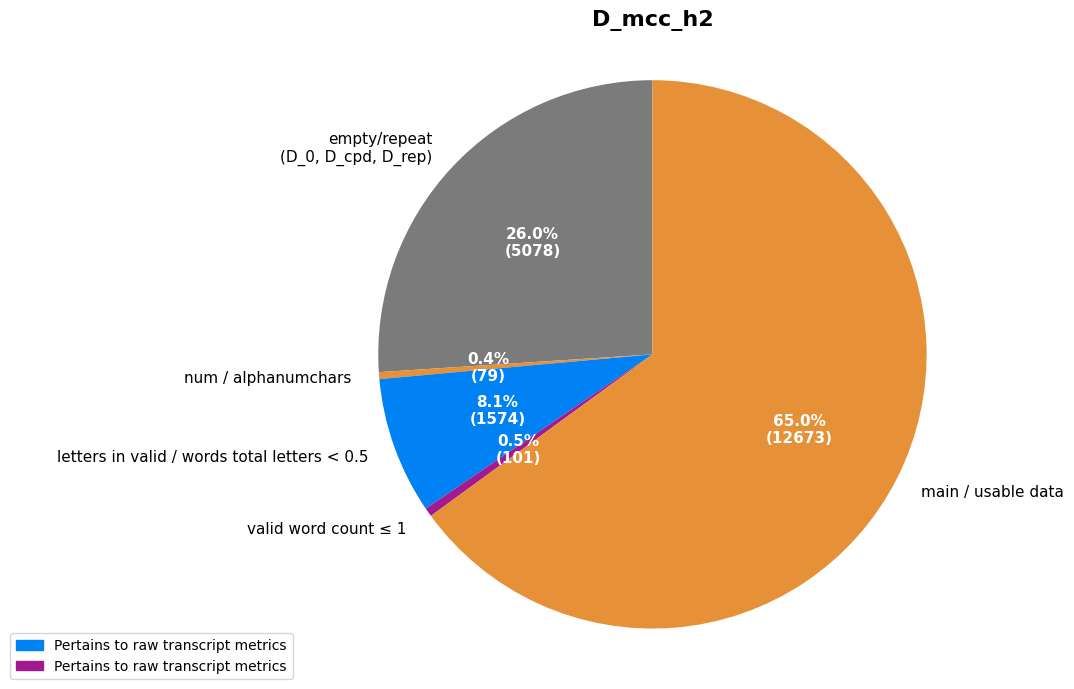

In [46]:
import matplotlib.patches as mpatches

# Counts
round_one_iso = 5078 # gray
num_sep_r = num_sep_count  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) # orange

# data
categories = ['empty/repeat\n(D_0, D_cpd, D_rep)', 'num / alphanumchars', 'letters in valid / words total letters < 0.5', 'valid word count ≤ 1', 'main / usable data']
values = [round_one_iso, num_sep_r, r2_part_1, r2_part_2, rest]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", '#e69138', "#0082f4", "#a11a8f", '#e69138'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title('D_mcc_h2', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

p1 = mpatches.Patch(color="#0082f4", label='Pertains to raw transcript metrics')
p2 = mpatches.Patch(color="#a11a8f", label='Pertains to raw transcript metrics')
plt.legend(handles=[p1, p2], loc='center right', bbox_to_anchor=(-0.05, 0))
plt.tight_layout()


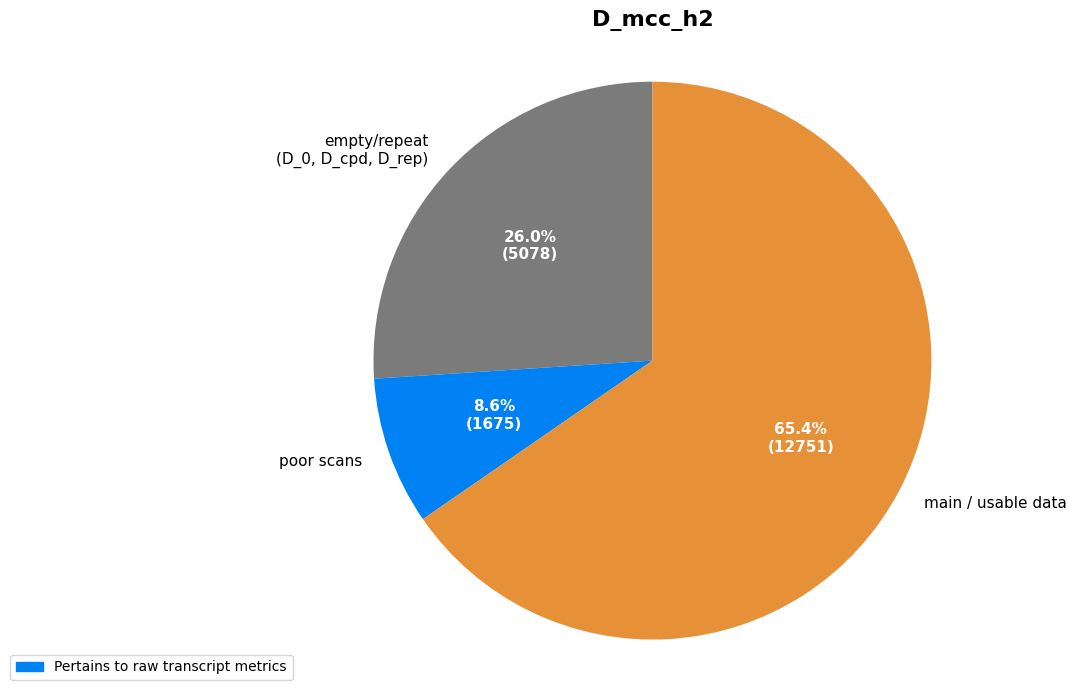

In [47]:
# Counts
round_one_iso = 5078 # gray
num_sep_r = num_sep_count  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) # orange

# data
categories = ['empty/repeat\n(D_0, D_cpd, D_rep)', 'poor scans', 'main / usable data']
values = [round_one_iso, r2_part_1 + r2_part_2, rest+num_sep_r]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", "#0082f4", '#e69138'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title('D_mcc_h2', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

p1 = mpatches.Patch(color="#0082f4", label='Pertains to raw transcript metrics')
plt.legend(handles=[p1], loc='center right', bbox_to_anchor=(-0.05, 0))
plt.tight_layout()


In [48]:
# combine num_sep and main into one
combined = pd.concat([valid, num_sep], ignore_index=True)
print(f"Len combined: {len(combined)}")
save_csv(combined, f"../data/{dataset}/split_data/h2_split/training/D_{dataset[0:3]}_h2_main+nums.csv")

Len combined: 12752
